In [17]:
import pandas as pd
import numpy as np
import seaborn as sns

<h1>Dataset View</h1>

In [19]:
df = pd.read_excel("Dataset.xlsx")
df.head()

,Date,Day,Weather,Category,Food_Item,Temperature,IsWeekend,IsHoliday,Quantity_Sold
0,16-07-2025,Wednesday,Rainy,Veg,Veg Biryani,27.7,0,0,88
1,08-09-2025,Monday,Cloudy,Non-Veg,Egg Rice,28.3,0,0,134
2,13-09-2025,Saturday,Cloudy,Non-Veg,Chicken Noodles,27.8,1,0,148
3,19-07-2025,Saturday,Sunny,Non-Veg,Egg Curry,23.6,1,0,30
4,24-08-2025,Sunday,Sunny,Non-Veg,Chicken Biryani,29.7,1,1,21


<h1> Data Preprocessing </h1>

In [22]:
df.isnull()

,Date,Day,Weather,Category,Food_Item,Temperature,IsWeekend,IsHoliday,Quantity_Sold
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
195,False,False,False,False,False,False,False,False,False
196,False,False,False,False,False,False,False,False,False
197,False,False,False,False,False,False,False,False,False
198,False,False,False,False,False,False,False,False,False


In [24]:
df.isnull().sum()

Date             0
Day              0
Weather          0
Category         0
Food_Item        0
Temperature      0
IsWeekend        0
IsHoliday        0
Quantity_Sold    0
dtype: int64

In [26]:
df.isnull().sum().sum()

0

<h1> Data Visualization </h1>

<Axes: >

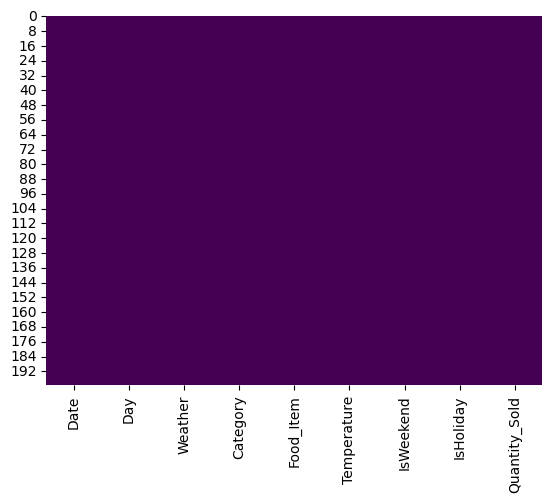

In [28]:
sns.heatmap(df.isnull(), cmap='viridis', cbar=False)

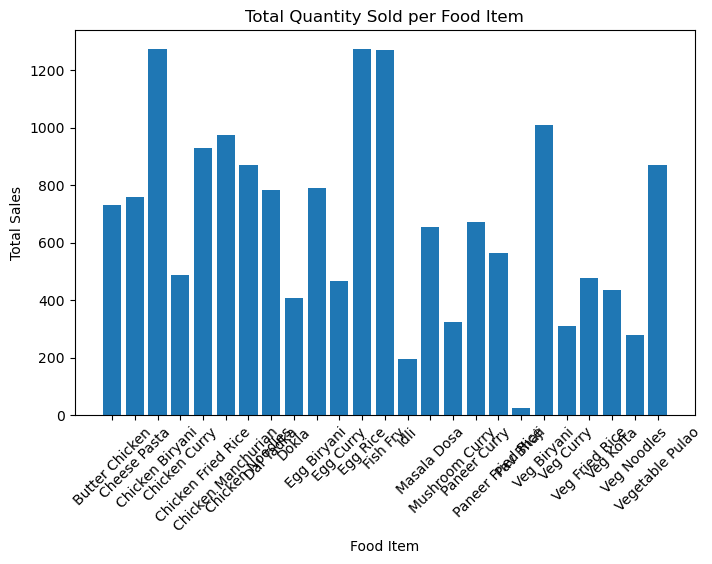

In [30]:
import matplotlib.pyplot as plt

item_sales = df.groupby('Food_Item')['Quantity_Sold'].sum()

plt.figure(figsize=(8,5))
plt.bar(item_sales.index, item_sales.values)
plt.title("Total Quantity Sold per Food Item")
plt.xlabel("Food Item")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.show()

In [32]:
print("Total Unique Food Items:", df['Food_Item'].nunique())
print("Unique Food Item Names:")
print(df['Food_Item'].unique())

Total Unique Food Items: 25
Unique Food Item Names:
['Veg Biryani' 'Egg Rice' 'Chicken Noodles' 'Egg Curry' 'Chicken Biryani'
 'Paneer Curry' 'Dokla' 'Mushroom Curry' 'Fish Fry' 'Chicken Manchurian'
 'Cheese Pasta' 'Chicken Curry' 'Masala Dosa' 'Egg Biryani' 'Veg Noodles'
 'Chicken Fried Rice' 'Butter Chicken' 'Vegetable Pulao' 'Dal Tadka'
 'Idli' 'Veg Fried Rice' 'Paneer Fried Rice' 'Veg Kofta' 'Veg Curry'
 'Pav Bhaji']


C:\Users\Neeharika Reddy G\AppData\Local\Temp\ipykernel_6524\452488698.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


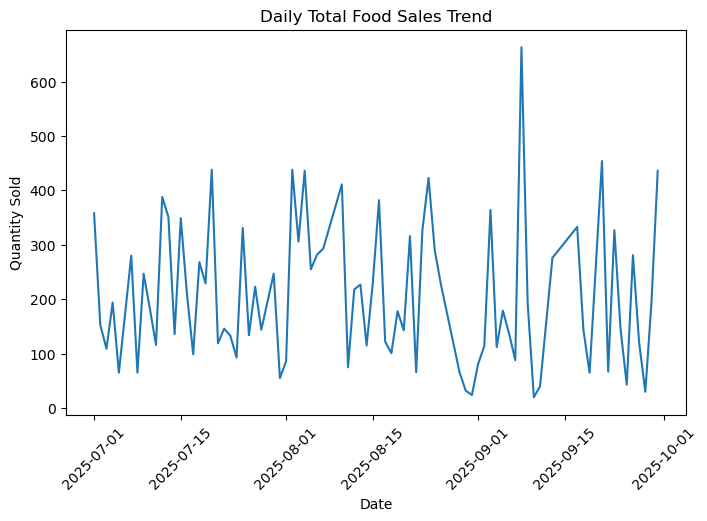

In [34]:
df['Date'] = pd.to_datetime(df['Date'])

daily_sales = df.groupby('Date')['Quantity_Sold'].sum()

plt.figure(figsize=(8,5))
plt.plot(daily_sales.index, daily_sales.values)
plt.title("Daily Total Food Sales Trend")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

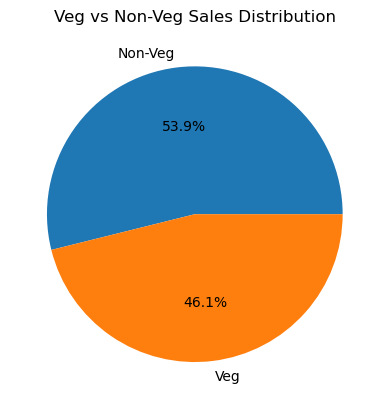

In [36]:
category_sales = df.groupby('Category')['Quantity_Sold'].sum()

plt.figure()
plt.pie(category_sales, labels=category_sales.index, autopct="%1.1f%%")
plt.title("Veg vs Non-Veg Sales Distribution")
plt.show()

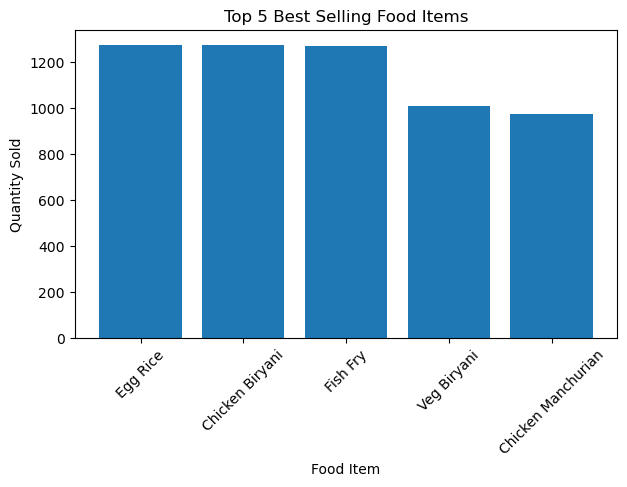

In [38]:
top_items = df.groupby('Food_Item')['Quantity_Sold'].sum().sort_values(ascending=False).head(5)

plt.figure(figsize=(7,4))
plt.bar(top_items.index, top_items.values)
plt.title("Top 5 Best Selling Food Items")
plt.xlabel("Food Item")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)
plt.show()

<h1> Model Training</h1>

In [40]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [46]:
X = df[['Temperature', 'IsWeekend', 'IsHoliday']]
y = df['Quantity_Sold']

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

<h1> Linear Regression </h1>

In [52]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [54]:
y_pred = model.predict(X_test)

In [56]:
print("🔹 Linear Regression Results")
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

🔹 Linear Regression Results
R2 Score: -0.2690843311653315
MAE: 36.94038610039525
MSE: 1905.5904047504755
RMSE: 43.65306867507112


<h1> Random Forest </h1>

In [59]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [61]:
y_pred_rf = rf_model.predict(X_test)

In [63]:
print("Random Forest Accuracy (R2 Score):", r2_score(y_test, y_pred_rf))

Random Forest Accuracy (R2 Score): -0.6183893586495048


In [67]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("📊 Random Forest Regression Results:")
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

📊 Random Forest Regression Results:
R2 Score: -0.2690843311653315
MAE: 36.94038610039525
MSE: 1905.5904047504755
RMSE: 43.65306867507112


<h1> LSTM </h1>

In [79]:
# 📌 Import Libraries
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 📌 Load Dataset
df = pd.read_excel("Dataset.xlsx")

# Keep main numeric features
df = df[['Temperature', 'IsHoliday', 'IsWeekend', 'Quantity_Sold']]

# 📌 Feature Scaling
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df)

# Convert to NumPy
data = np.array(scaled_data)

# 📌 Create Time Series sequences (last 7 days → next day prediction)
X = []
y = []
window_size = 7

for i in range(window_size, len(data)):
    X.append(data[i-window_size:i, :-1])   # features except target
    y.append(data[i, -1])                  # target: Quantity_Sold

X, y = np.array(X), np.array(y)

# 📌 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# 📌 LSTM Model
model = Sequential()
model.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(Dropout(0.2))
model.add(LSTM(units=50))
model.add(Dropout(0.2))
model.add(Dense(units=1))   # Output: Quantity Sold

model.compile(optimizer='adam', loss='mean_squared_error')

# 📌 Train Model
history = model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.1)

# 📌 Prediction
y_pred = model.predict(X_test)

# Inverse scaling to get real values
y_test_real = scaler.inverse_transform(np.concatenate((X_test[:, -1, :], y_test.reshape(-1, 1)), axis=1))[:, -1]
y_pred_real = scaler.inverse_transform(np.concatenate((X_test[:, -1, :], y_pred), axis=1))[:, -1]

# 📌 Evaluation Metrics
print("MAE:", mean_absolute_error(y_test_real, y_pred_real))
print("MSE:", mean_squared_error(y_test_real, y_pred_real))
print("RMSE:", np.sqrt(mean_squared_error(y_test_real, y_pred_real)))
print("R2 Score:", r2_score(y_test_real, y_pred_real))

C:\Users\Neeharika Reddy G\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 10s 231ms/step - loss: 0.3080 - val_loss: 0.1385
Epoch 2/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 0.1694 - val_loss: 0.0694
Epoch 3/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1088 - val_loss: 0.0792
Epoch 4/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 0.1190 - val_loss: 0.0689
Epoch 5/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.1169 - val_loss: 0.0636
Epoch 6/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 0.1090 - val_loss: 0.0651
Epoch 7/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.1075 - val_loss: 0.0642
Epoch 8/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0978 - val_loss: 0.0634
Epoch 9/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 0.0997 - val_loss: 0.0642
Epoch 10/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - loss: 0.1031 - val_loss: 0.0641
Epoch 11/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1033 - val_loss: 0.0635
Epoch 12/50
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.1062 - val_loss: 0.0633

In [91]:
# 📌 Evaluation Metrics
print("LSTM Model Results")
print("MAE:", mean_absolute_error(y_test_real, y_pred_real))
print("MSE:", mean_squared_error(y_test_real, y_pred_real))
print("RMSE:", np.sqrt(mean_squared_error(y_test_real, y_pred_real)))
print("R2 Score:", r2_score(y_test_real, y_pred_real))

LSTM Model Results
MAE: 29.278056484002335
MSE: 1188.319209112138
RMSE: 34.472006166049255
R2 Score: 0.01918532296739417


In [93]:
import pandas as pd

# Model performance results
results = {
    'Model': ['Linear Regression', 'Random Forest', 'LSTM'],
    'R2 Score': [-0.26908, -0.26908, 0.01918],
    'MAE': [36.94, 36.94, 29.28],
    'MSE': [1905.59, 1905.59, 1188.32],
    'RMSE': [43.65, 43.65, 34.47]
}

results_df = pd.DataFrame(results)
print(results_df)

               Model  R2 Score    MAE      MSE   RMSE
0  Linear Regression  -0.26908  36.94  1905.59  43.65
1      Random Forest  -0.26908  36.94  1905.59  43.65
2               LSTM   0.01918  29.28  1188.32  34.47


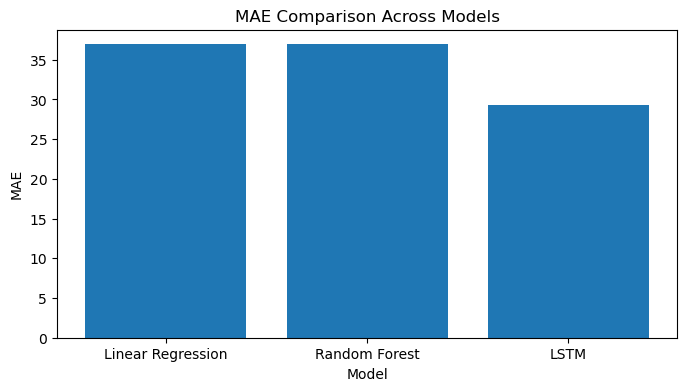

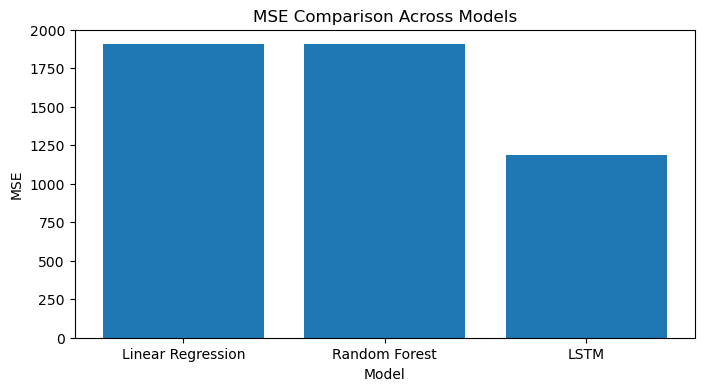

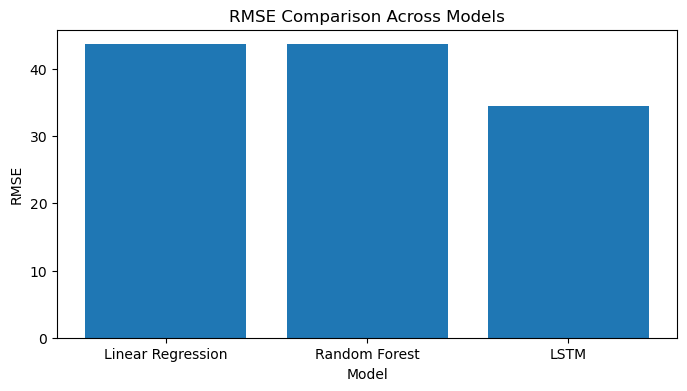

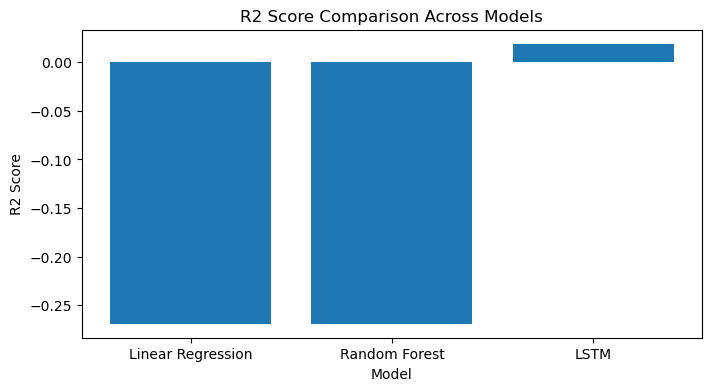

In [95]:
import matplotlib.pyplot as plt

# Plot metrics comparison
metrics = ['MAE', 'MSE', 'RMSE', 'R2 Score']
models = results_df['Model']

for metric in metrics:
    plt.figure(figsize=(8,4))
    plt.bar(models, results_df[metric])
    plt.title(f'{metric} Comparison Across Models')
    plt.xlabel('Model')
    plt.ylabel(metric)
    plt.show()


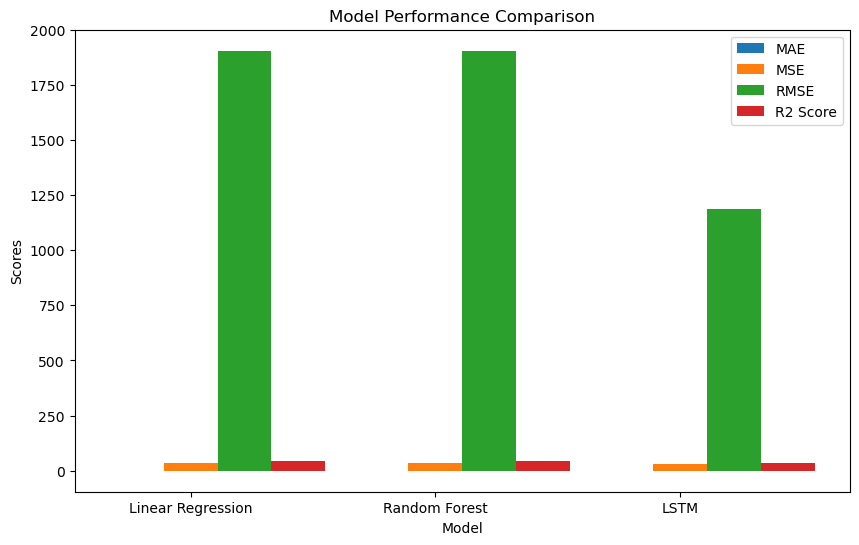

In [97]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['MAE', 'MSE', 'RMSE', 'R2 Score']
models = results_df['Model']
values = results_df.drop('Model', axis=1).values

x = np.arange(len(models))  
width = 0.22  

plt.figure(figsize=(10,6))
for i in range(len(metrics)):
    plt.bar(x + i*width, values[:, i], width, label=metrics[i])

plt.xlabel('Model')
plt.ylabel('Scores')
plt.title('Model Performance Comparison')
plt.xticks(x + width, models)
plt.legend()
plt.show()


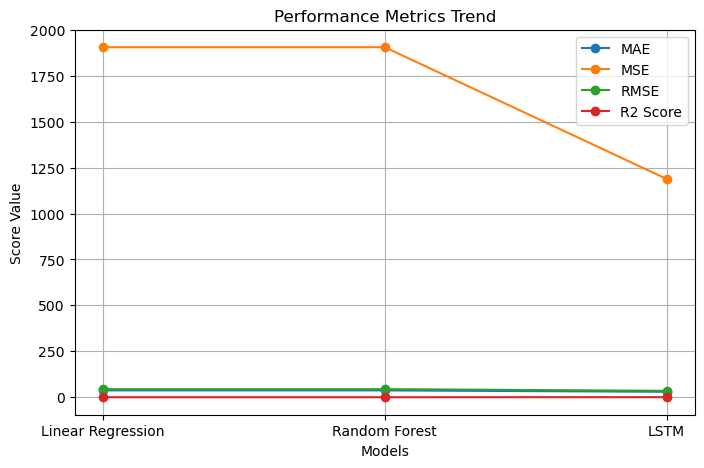

In [99]:
plt.figure(figsize=(8,5))
for metric in metrics:
    plt.plot(models, results_df[metric], marker='o', label=metric)

plt.title('Performance Metrics Trend')
plt.xlabel('Models')
plt.ylabel('Score Value')
plt.legend()
plt.grid(True)
plt.show()


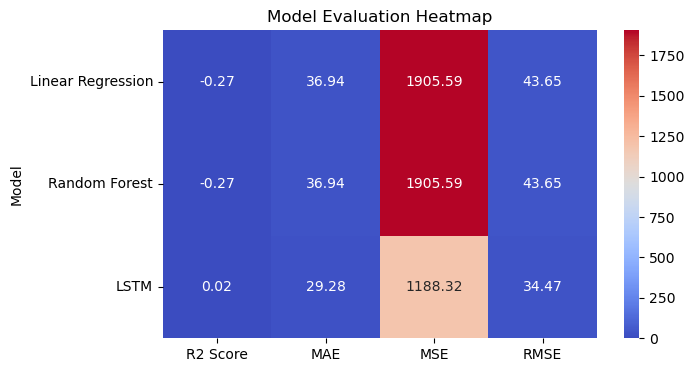

In [101]:
import seaborn as sns
plt.figure(figsize=(7,4))
sns.heatmap(results_df.set_index('Model'), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Model Evaluation Heatmap")
plt.show()